In [2]:
!nvidia-smi

Sun Jun  9 00:45:40 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.129.03             Driver Version: 535.129.03   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              10W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [3]:
!pip install ultralytics==8.0.196

from IPython import display
display.clear_output()

import os

import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.0.196 🚀 Python-3.10.13 torch-2.1.2 CUDA:0 (Tesla T4, 15102MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 5689.3/8062.4 GB disk)


In [4]:
from ultralytics import YOLO
!yolo = mode = checks

Traceback (most recent call last):
  File "/opt/conda/bin/yolo", line 8, in <module>
    sys.exit(entrypoint())
  File "/opt/conda/lib/python3.10/site-packages/ultralytics/cfg/__init__.py", line 385, in entrypoint
    check_dict_alignment(full_args_dict, overrides)
  File "/opt/conda/lib/python3.10/site-packages/ultralytics/cfg/__init__.py", line 203, in check_dict_alignment
    raise SyntaxError(string + CLI_HELP_MSG) from e
SyntaxError: '' is not a valid YOLO argument. 

    Arguments received: ['yolo', '=', 'mode', '=', 'checks']. Ultralytics 'yolo' commands use the following syntax:

        yolo TASK MODE ARGS

        Where   TASK (optional) is one of ('detect', 'segment', 'classify', 'pose')
                MODE (required) is one of ('train', 'val', 'predict', 'export', 'track', 'benchmark')
                ARGS (optional) are any number of custom 'arg=value' pairs like 'imgsz=320' that override defaults.
                    See all ARGS at https://docs.ultralytics.com/usage/cfg

In [5]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="WsP1J5o6ETVNcwCEBRZ4")
project = rf.workspace("project-efzqj").project("pfe-avhta")
version = project.version(8)
dataset = version.download("yolov8")

Reason for being yanked: deprecated, use 4.8.0.76
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.3/158.3 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.1/49.1 MB 34.8 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.10.0.82
    Uninstalling opencv-python-headless-4.10.0.82:
      Successfully uninstalled opencv-python-headless-4.10.0.82
  Attempting uninstall: idna
    Found existing installation: idna 3.6
    Uninstalling idna-3.6:
      Successfully uninstalled idna-3.6
  Attempting uninstall: cycler
    Found existing installation: cycler 0.12.1
    Uninstalling cycler-0.12.1:
      Successfully uninstalled cycler-0.12.1
  Attempting uninstall


Extracting Dataset Version Zip to PFE-8 in yolov8:: 100%|██████████| 16016/16016 [00:02<00:00, 7393.02it/s]


In [6]:
import yaml

# Path to the dataset configuration file
dataset_config_path = "/content/PFE-8/data.yaml"

# Load the dataset configuration file
with open(dataset_config_path, 'r') as file:
    dataset_config = yaml.safe_load(file)

# Print the class names and count the number of classes
class_names = dataset_config.get('names', [])
num_classes = len(class_names)

print(f"Class Names: {class_names}")
print(f"Number of Classes: {num_classes}")

FileNotFoundError: [Errno 2] No such file or directory: '/content/PFE-8/data.yaml'

In [7]:
!yolo task=detect mode=train model=yolov8m.pt data={dataset.location}/data.yaml epochs=50 imgsz=640 batch=16 lr0 = 0.001

100%|███████████████████████████████████████| 49.7M/49.7M [00:00<00:00, 168MB/s]
New https://pypi.org/project/ultralytics/8.2.29 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.0.196 🚀 Python-3.10.13 torch-2.1.2 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolov8m.pt, data=/kaggle/working/PFE-8/data.yaml, epochs=50, patience=50, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=None, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, show=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, vid_str

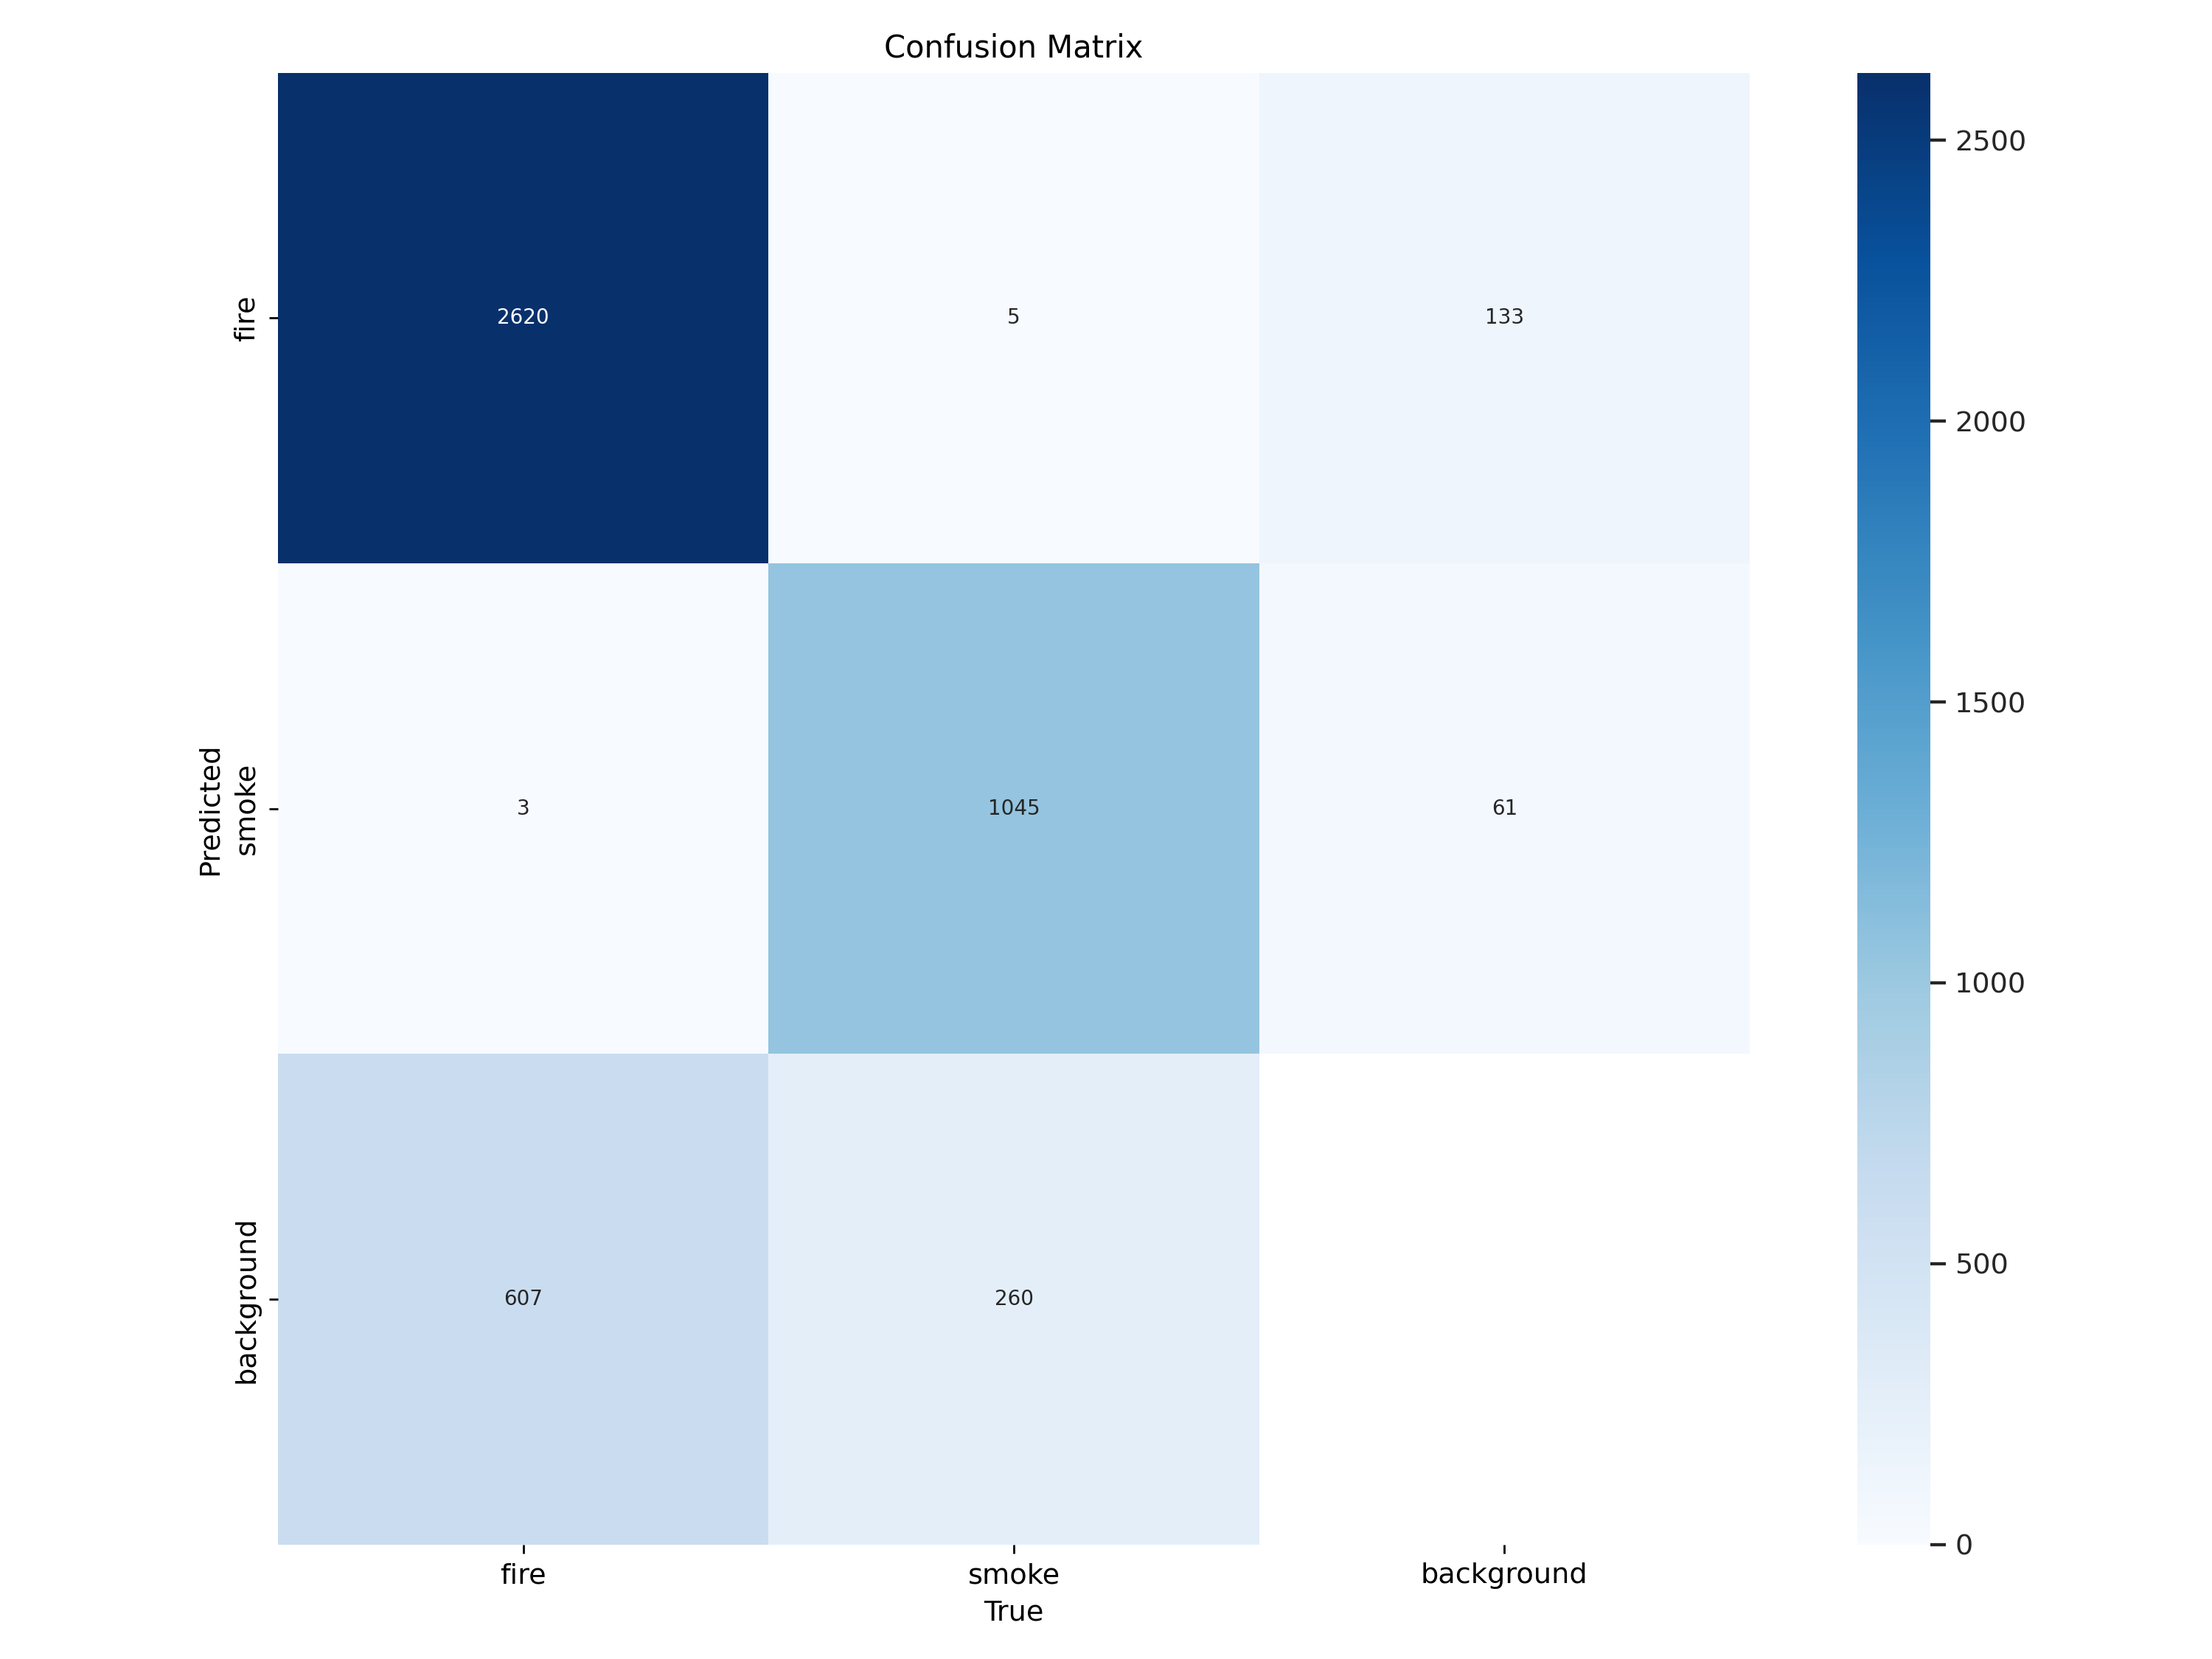

In [16]:
Image(filename= '/kaggle/working/runs/detect/train/confusion_matrix.png', width=600)

In [12]:
from IPython.display import Image, display

In [ ]:
Image(filename=f'/runs/detect/train/results.png', width=600)

In [10]:
project.version(dataset.version).deploy(model_type="yolov8", model_path="/kaggle/working/runs/detect/train")

View the status of your deployment at: https://app.roboflow.com/project-efzqj/pfe-avhta/8
Share your model with the world at: https://universe.roboflow.com/project-efzqj/pfe-avhta/model/8
